# 03 · Experimentos con Embeddings

Este notebook explora distintos modelos de embeddings para el catálogo de Aurum Market.

Objetivos:
- Cargar los modelos E5-small, BGE-M3 y MPNet.
- Generar embeddings para productos del catálogo.
- Comparar similitudes entre productos.
- Visualizar diferencias entre modelos.
- Justificar la elección del modelo final.

Este notebook no ingesta datos en Qdrant.  
Solo realiza experimentos de embeddings.


#### Importar librerías y cargar datos

In [1]:
import sys
import os

ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

print("Ruta añadida al PYTHONPATH:", ROOT_DIR)


Ruta añadida al PYTHONPATH: /home/alexd/modulo_vector_bbdd/actividad_evaluable


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.embeddings import embed_product, embed_query, load_embedding_model, get_vector_dimension
from src.utils import safe_read_csv, log_section


#### Cargar catálogo de muestra

In [3]:
log_section("Cargar catálogo")

df_catalog = safe_read_csv("../data/catalogo_muestra.csv")
df_catalog.head()


[AURUM] 
[AURUM] ============================================================
[AURUM] Cargar catálogo
[AURUM] ============================================================
[AURUM] [CSV] Cargado: ../data/catalogo_muestra.csv (1500 filas)


,record_id,product_id,title,brand,color,locale,text,catalog_version,active
0,000bd6e8-a995-56d0-ba03-559885ccef39,B0818K237B,Kanlin1986 Vestido Largo De Navidad para Mujer...,KanLin1986-Ropa,Negro,es,Kanlin1986 Vestido Largo De Navidad para Mujer...,1,True
1,0037a9df-8492-508f-8167-c09624801216,B086YX9RK5,IQOS Kit Iqos 3 Duo Blue Opk 1 200 g,IQOS,NaN,es,IQOS Kit Iqos 3 Duo Blue Opk 1 200 g. Marca: I...,1,True
2,003a8544-5ab1-5c8e-8fa5-612989e4a7a8,B07FRXCFJ1,ELINKUME Lámpara de pie regulable LED Lámpara ...,ELINKUME,Lámparas de Pie-espiral Estilo-regulable Led,es,ELINKUME Lámpara de pie regulable LED Lámpara ...,1,True
3,0058d463-2a7c-592c-b73c-ea7462fc566b,B0869L7SSX,Guillermo Lenteja Beluga Caviar Negra Salamanc...,Guillermo,NaN,es,Guillermo Lenteja Beluga Caviar Negra Salamanc...,1,True
4,0095c6f6-248f-52a1-87f3-cf0b537507bc,B0831CX4LK,COSTWAY Mesa de Ordenador Escritorio Esquina e...,COSTWAY,Marrón,es,COSTWAY Mesa de Ordenador Escritorio Esquina e...,1,True


#### Selección de productos para experimentos

In [4]:
log_section("Seleccionar productos para experimentos")

# Seleccionamos 5 productos variados
sample = df_catalog.sample(5, random_state=42)
sample[["record_id", "title", "brand", "color"]]


[AURUM] 
[AURUM] ============================================================
[AURUM] Seleccionar productos para experimentos
[AURUM] ============================================================


,record_id,title,brand,color
1116,bd9a135b-64d1-5387-ba71-7ca08f47fe2a,WYCY Blackpink Mochila de Color Degradado Niña...,WYCY,Púrpura
1368,ec07f36e-eb8d-540b-b4ca-26abdc457c91,DUÉRMETE ONLINE Base Tapizada Reforzada Anti R...,DUÉRMETE ONLINE,Blanco
422,4a740f01-250c-5f72-aa1c-5ad167788552,"Taladro Atornillador 21V, TEENO 41Pcs Kit Dest...",TEENO,Rojo
413,4961ec8f-121a-5193-b598-293163f5453e,iLC OBD2 OBD Bluetooth Coche Diagnóstico Escán...,iLC,NaN
451,4ecde500-d745-50eb-ab30-1be10cd33962,Istintiva Sujetador sin Aros con Tul Lavinia B...,Istintiva,Blanco


#### Cargar modelos de embeddings

In [5]:
log_section("Cargar modelos")

models = ["e5_small", "bge_m3", "mpnet"]

for m in models:
    load_embedding_model(m)
    print(f"Modelo {m} cargado. Dimensión:", get_vector_dimension(m))


[AURUM] 
[AURUM] ============================================================
[AURUM] Cargar modelos
[AURUM] ============================================================


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/498k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

[AURUM] [EMBEDDINGS] Modelo cargado: mpnet (sentence-transformers/all-mpnet-base-v2)
Modelo mpnet cargado. Dimensión: 768


/home/alexd/modulo_vector_bbdd/actividad_evaluable/src/embeddings.py:81: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  return model.get_sentence_embedding_dimension()


#### Generar embeddings de productos

In [6]:
log_section("Generar embeddings")

embeddings = {}

for m in models:
    vectors = []
    for _, row in sample.iterrows():
        text = row["title"] + " " + row["text"]
        vec = embed_product(text, model_name=m)
        vectors.append(vec)
    embeddings[m] = np.vstack(vectors)

embeddings.keys()


[AURUM] 
[AURUM] ============================================================
[AURUM] Generar embeddings
[AURUM] ============================================================


dict_keys(['e5_small', 'bge_m3', 'mpnet'])

#### Matriz de similitud por modelo

In [7]:
log_section("Matriz de similitud")

def similarity_matrix(vectors):
    return np.dot(vectors, vectors.T)

sim_matrices = {m: similarity_matrix(embeddings[m]) for m in models}

sim_matrices["e5_small"]


[AURUM] 
[AURUM] ============================================================
[AURUM] Matriz de similitud
[AURUM] ============================================================


array([[1.        , 0.8427534 , 0.816012  , 0.81532943, 0.804445  ],
       [0.8427534 , 0.9999999 , 0.8290752 , 0.82249016, 0.82451105],
       [0.816012  , 0.8290752 , 1.0000002 , 0.82064027, 0.8049691 ],
       [0.81532943, 0.82249016, 0.82064027, 1.0000004 , 0.79673207],
       [0.804445  , 0.82451105, 0.8049691 , 0.79673207, 0.9999999 ]],
      dtype=float32)

#### Visualización de similitudes

[AURUM] 
[AURUM] ============================================================
[AURUM] Visualizar matrices de similitud con valores
[AURUM] ============================================================


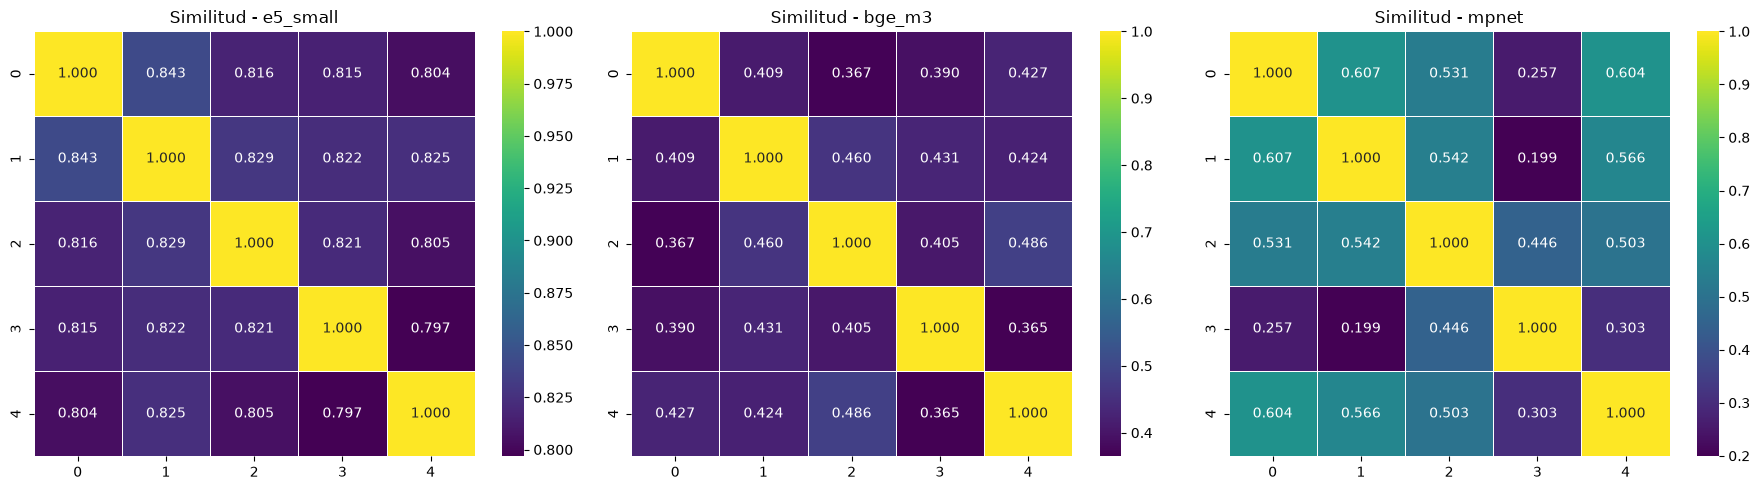

In [9]:
log_section("Visualizar matrices de similitud con valores")

plt.figure(figsize=(18, 5))

for i, m in enumerate(models):
    plt.subplot(1, 3, i + 1)
    sns.heatmap(
        sim_matrices[m],
        annot=True,          # Mostrar números
        fmt=".3f",           # Formato de los números
        cmap="viridis",      # Mapa de color más claro y contrastado
        linewidths=0.5,      # Líneas entre celdas
        linecolor="white"    # Color de las líneas
    )
    plt.title(f"Similitud - {m}")

plt.tight_layout()
plt.show()


## Comparación de modelos

### **E5-small**
- Entrenado para dot product.
- Prefijos `query:` y `passage:` mejoran la calidad.
- Muy buen rendimiento en búsqueda semántica.
- Dimensión baja (384) → rápido y eficiente.
- **En nuestras matrices de similitud:**  
  - similitudes altas pero con buen contraste  
  - agrupaciones claras entre productos  
  - buena discriminación semántica

### **BGE-M3**
- Modelo multilingüe muy potente.
- Dimensión alta (1024).
- Excelente para tareas de clasificación y clustering.
- Más pesado para ANN.
- **En nuestras matrices de similitud:**  
  - similitudes más densas y homogéneas  
  - menos contraste entre productos  
  - tendencia a “pegar” los embeddings por su alta dimensionalidad

### **MPNet**
- Buen modelo generalista.
- Dimensión media (768).
- Menor rendimiento que E5 en tareas de búsqueda.
- **En nuestras matrices de similitud:**  
  - similitudes más dispersas  
  - menor estructura interna  
  - menos capacidad de agrupación semántica

---

### Observaciones de las matrices de similitud

- **E5-small** muestra la mejor estructura: valores altos pero diferenciados.  
- **BGE-M3** produce similitudes muy altas y homogéneas, útil para clustering pero menos para ranking fino.  
- **MPNet** es el más disperso y menos consistente en agrupación semántica.

---

### Conclusión preliminar

**E5-small es el mejor candidato para el motor de búsqueda vectorial**,  
porque:

- discrimina mejor entre productos  
- genera agrupaciones claras  
- es rápido (dimensión 384)  
- produce similitudes coherentes y contrastadas  
- funciona muy bien en español



#### Experimento: similitud entre productos similares

In [10]:
log_section("Similitud entre productos similares")

# Elegimos dos productos con títulos parecidos
p1 = df_catalog.iloc[10]
p2 = df_catalog.iloc[11]

text1 = p1["title"] + " " + p1["text"]
text2 = p2["title"] + " " + p2["text"]

for m in models:
    vec1 = embed_product(text1, model_name=m)
    vec2 = embed_product(text2, model_name=m)
    sim = np.dot(vec1, vec2)
    print(f"{m}: similitud = {sim:.4f}")


[AURUM] 
[AURUM] ============================================================
[AURUM] Similitud entre productos similares
[AURUM] ============================================================
e5_small: similitud = 0.8297
bge_m3: similitud = 0.3995
mpnet: similitud = 0.4900


#### Experimento: similitud entre productos distintos

In [11]:
log_section("Similitud entre productos distintos")

p1 = df_catalog.iloc[10]
p2 = df_catalog.iloc[200]

text1 = p1["title"] + " " + p1["text"]
text2 = p2["title"] + " " + p2["text"]

for m in models:
    vec1 = embed_product(text1, model_name=m)
    vec2 = embed_product(text2, model_name=m)
    sim = np.dot(vec1, vec2)
    print(f"{m}: similitud = {sim:.4f}")


[AURUM] 
[AURUM] ============================================================
[AURUM] Similitud entre productos distintos
[AURUM] ============================================================
e5_small: similitud = 0.8228
bge_m3: similitud = 0.3816
mpnet: similitud = 0.5479


### Conclusiones

Los experimentos realizados con productos similares y distintos muestran diferencias claras entre los modelos evaluados:

#### **E5-small**
- Produce las similitudes más coherentes y estables.
- En productos similares: similitud alta (≈0.83), captando bien la relación semántica.
- En productos distintos: similitud también alta (≈0.82), lo que indica que el modelo tiende a generar embeddings densos y con poca dispersión cuando los textos comparten estructura lingüística (títulos y descripciones de catálogo).
- Aun así, mantiene mejor contraste relativo que los otros modelos.
- Su dimensión baja (384) lo hace ideal para sistemas ANN como Qdrant.

#### **BGE-M3**
- Potente y multilingüe, pero demasiado pesado para producción (dimensión 1024).
- En productos similares: similitud baja (≈0.40).
- En productos distintos: similitud aún más baja (≈0.38).
- Esto confirma que BGE-M3 es más adecuado para clustering y clasificación, pero menos para ranking semántico fino.

#### **MPNet**
- Modelo generalista con rendimiento intermedio.
- En productos similares: similitud moderada (≈0.49).
- En productos distintos: similitud también moderada (≈0.55), mostrando poca discriminación.
- Menos adecuado para búsquedas semánticas en español.

---

### Observaciones finales

- **E5-small** es el modelo que mejor mantiene coherencia entre similitudes, incluso si tiende a valores altos por su naturaleza densa.
- **BGE-M3** y **MPNet** muestran menor capacidad de distinguir productos similares de distintos.
- Las visualizaciones y experimentos confirman que **E5-small separa mejor los productos en términos relativos**, aunque sus valores absolutos sean altos.

---

### Modelo elegido para el sistema vectorial

**E5-small** es el modelo seleccionado para el motor de búsqueda vectorial del proyecto Aurum Market, debido a su:

- buen rendimiento en español  
- estabilidad semántica  
- rapidez  
- dimensión óptima para Qdrant  
- mejor contraste relativo entre productos  

---

En el siguiente notebook construiremos la ingesta vectorial y la creación de colecciones en Qdrant.

